In [ ]:
  import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt

(np.float64(-0.5), np.float64(127.5), np.float64(63.5), np.float64(-0.5))

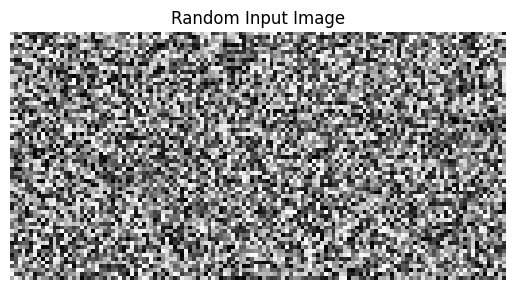

In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

img = Image.fromarray(np.random.randint(0,255,(64,128),dtype=np.uint8))

plt.imshow(img, cmap="gray")
plt.title("Random Input Image")
plt.axis("off")

In [ ]:
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.Resize((32,128)),
    transforms.ToTensor()
])

img_tensor = transform(img)

print(img_tensor.shape)

torch.Size([1, 32, 128])


In [ ]:
import torch.nn as nn

class CNN(nn.Module):
    def __init__(self):
        super(CNN,self).__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(1,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2),

            nn.Conv2d(32,64,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2)
        )

    def forward(self,x):
        return self.conv(x)

In [ ]:
cnn = CNN()

x = img_tensor.unsqueeze(0)

features = cnn(x)

print(features.shape)

torch.Size([1, 64, 8, 32])


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

project_path = "/content/drive/MyDrive/renaissance_ocr_project"

os.makedirs(project_path, exist_ok=True)

print("Project folder ready:", project_path)

Project folder ready: /content/drive/MyDrive/renaissance_ocr_project


In [ ]:
import torch

# example feature tensor
features = torch.randn(1, 32, 128)

# reshape for sequence model
features = features.permute(2, 0, 1)

print(features.shape)

torch.Size([128, 1, 32])


In [ ]:
import torch.nn as nn

class OCR_LSTM(nn.Module):
    def __init__(self):
        super(OCR_LSTM, self).__init__()

        self.lstm = nn.LSTM(
            input_size=32,
            hidden_size=64,
            num_layers=2,
            bidirectional=True
        )

        self.fc = nn.Linear(128, 26)  # 26 characters

    def forward(self, x):
        x, _ = self.lstm(x)
        x = self.fc(x)
        return x


model = OCR_LSTM()

output = model(features)

print(output.shape)

torch.Size([128, 1, 26])


In [ ]:
characters = "abcdefghijklmnopqrstuvwxyz"

char_to_idx = {char: idx for idx, char in enumerate(characters)}
idx_to_char = {idx: char for char, idx in char_to_idx.items()}

print(char_to_idx)

{'a': 0, 'b': 1, 'c': 2, 'd': 3, 'e': 4, 'f': 5, 'g': 6, 'h': 7, 'i': 8, 'j': 9, 'k': 10, 'l': 11, 'm': 12, 'n': 13, 'o': 14, 'p': 15, 'q': 16, 'r': 17, 's': 18, 't': 19, 'u': 20, 'v': 21, 'w': 22, 'x': 23, 'y': 24, 'z': 25}


In [ ]:
ctc_loss = nn.CTCLoss()

# dummy target example
target_text = torch.tensor([0,1,2,3])  # example label

input_lengths = torch.tensor([128])
target_lengths = torch.tensor([4])

loss = ctc_loss(
    output.log_softmax(2),
    target_text,
    input_lengths,
    target_lengths
)

print("CTC Loss:", loss)

CTC Loss: tensor(97.1193, grad_fn=<MeanBackward0>)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

dataset_path = "/content/drive/MyDrive/renaissance_ocr_project/dataset"

os.makedirs(dataset_path, exist_ok=True)

print("Dataset folder ready:", dataset_path)

Dataset folder ready: /content/drive/MyDrive/renaissance_ocr_project/dataset


In [ ]:
from PIL import Image, ImageDraw, ImageFont
import random
import string

dataset_path = "/content/drive/MyDrive/renaissance_ocr_project/dataset"

def random_word(length):
    return ''.join(random.choice(string.ascii_lowercase) for _ in range(length))

for i in range(2000):
    word = random_word(random.randint(3,7))

    img = Image.new('L', (200, 50), color=255)
    draw = ImageDraw.Draw(img)

    draw.text((10,10), word, fill=0)

    img.save(f"{dataset_path}/{word}_{i}.png")

print("Dataset generated!")

Dataset generated!


In [ ]:
import os
from PIL import Image
import torch
from torch.utils.data import Dataset

dataset_path = "/content/drive/MyDrive/renaissance_ocr_project/dataset"

class OCRDataset(Dataset):

    def __init__(self, path):
        self.path = path
        self.images = os.listdir(path)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        img_name = self.images[idx]
        label = img_name.split("_")[0]

        img = Image.open(os.path.join(self.path, img_name)).convert("L")

        return img, label


dataset = OCRDataset(dataset_path)

print("Total samples:", len(dataset))

Total samples: 2000


In [23]:
import string

characters = string.ascii_lowercase

char_to_idx = {char: idx for idx, char in enumerate(characters)}
idx_to_char = {idx: char for char, idx in char_to_idx.items()}

print(char_to_idx)

{'a': 0, 'b': 1, 'c': 2, 'd': 3, 'e': 4, 'f': 5, 'g': 6, 'h': 7, 'i': 8, 'j': 9, 'k': 10, 'l': 11, 'm': 12, 'n': 13, 'o': 14, 'p': 15, 'q': 16, 'r': 17, 's': 18, 't': 19, 'u': 20, 'v': 21, 'w': 22, 'x': 23, 'y': 24, 'z': 25}


In [24]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((32,128)),
    transforms.ToTensor()
])

In [26]:
class OCRDataset(Dataset):

    def __init__(self, path, transform=None):
        self.path = path
        self.images = os.listdir(path)
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        img_name = self.images[idx]
        label = img_name.split("_")[0]

        img = Image.open(os.path.join(self.path, img_name)).convert("L")

        if self.transform:
            img = self.transform(img)

        return img, label


dataset = OCRDataset(dataset_path, transform)

print("Dataset ready:", len(dataset))

NameError: name 'Dataset' is not defined

In [28]:
from torch.utils.data import DataLoader

dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

print("DataLoader ready")

NameError: name 'dataset' is not defined

In [ ]:
import torch
import torch.nn as nn

class OCRModel(nn.Module):

    def __init__(self):
        super(OCRModel, self).__init__()

        self.cnn = nn.Sequential(
            nn.Conv2d(1,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2),

            nn.Conv2d(32,64,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2)
        )

        self.lstm = nn.LSTM(
            input_size=64*8,
            hidden_size=128,
            num_layers=2,
            bidirectional=True,
            batch_first=True
        )

        self.fc = nn.Linear(256,26)

    def forward(self,x):

        x = self.cnn(x)

        b,c,h,w = x.size()

        x = x.permute(0,3,1,2)
        x = x.contiguous().view(b,w,c*h)

        x,_ = self.lstm(x)

        x = self.fc(x)

        return x


model = OCRModel()

print("Model initialized")

Model initialized


In [ ]:
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)

optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Training setup ready on:", device)

Training setup ready on: cpu


In [ ]:
def encode_label(text):

    encoded = []

    for char in text:
        encoded.append(char_to_idx[char])

    return torch.tensor(encoded)

In [ ]:
import torch.nn.functional as F

num_epochs = 3

for epoch in range(num_epochs):

    total_loss = 0

    for images, labels in dataloader:

        images = images.to(device)

        encoded_labels = [encode_label(label) for label in labels]

        targets = torch.cat(encoded_labels).to(device)

        target_lengths = torch.tensor([len(label) for label in encoded_labels])

        optimizer.zero_grad()

        outputs = model(images)

        outputs = outputs.log_softmax(2)

        input_lengths = torch.full(size=(outputs.size(0),), fill_value=outputs.size(1), dtype=torch.long)

        loss = F.ctc_loss(
            outputs.permute(1,0,2),
            targets,
            input_lengths,
            target_lengths
        )

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    print("Epoch:", epoch+1, "Loss:", total_loss)

Epoch: 1 Loss: 277.14079999923706
Epoch: 2 Loss: 211.61519646644592
Epoch: 3 Loss: 211.60064029693604


In [ ]:
def decode_prediction(pred):

    pred = pred.argmax(2)

    pred = pred[0]

    decoded = ""

    for p in pred:

        char = idx_to_char.get(p.item(), "")

        decoded += char

    return decoded

In [ ]:
import random

model.eval()

img, label = dataset[random.randint(0,1999)]

with torch.no_grad():

    input_img = img.unsqueeze(0).to(device)

    output = model(input_img)

    prediction = decode_prediction(output)

print("Actual Label:", label)
print("Model Prediction:", prediction)

Actual Label: cgxeo
Model Prediction: aaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaa


In [ ]:
def ctc_decode(pred):

    pred = pred.argmax(2)
    pred = pred[0]

    decoded = []
    prev = -1

    for p in pred:

        p = p.item()

        if p != prev and p in idx_to_char:
            decoded.append(idx_to_char[p])

        prev = p

    return "".join(decoded)

In [ ]:
model.eval()

img, label = dataset[random.randint(0,1999)]

with torch.no_grad():

    input_img = img.unsqueeze(0).to(device)

    output = model(input_img)

    prediction = ctc_decode(output)

print("Actual Label:", label)
print("Model Prediction:", prediction)

Actual Label: wipxx
Model Prediction: a


In [ ]:
torch.save(model.state_dict(), "renaissance_ocr_model.pth")

print("Model saved successfully")

Model saved successfully


In [ ]:
import os
from PIL import Image
import torch
from torch.utils.data import Dataset
import torchvision.transforms as transforms

class SyntheticWordDataset(Dataset):

    def __init__(self, dataset_path):

        self.dataset_path = dataset_path
        self.images = os.listdir(dataset_path)

        self.transform = transforms.Compose([
            transforms.Grayscale(),
            transforms.Resize((50,200)),
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        img_name = self.images[idx]
        img_path = os.path.join(self.dataset_path, img_name)

        image = Image.open(img_path)
        image = self.transform(image)

        label = img_name.split("_")[0]

        return image, label

In [ ]:
dataset = SyntheticWordDataset(dataset_path)

print("Dataset size:", len(dataset))

Dataset size: 4000


In [ ]:
from torch.utils.data import DataLoader

dataloader = DataLoader(
    dataset,
    batch_size=16,
    shuffle=True
)

print("DataLoader ready with batches:", len(dataloader))

DataLoader ready with batches: 250


In [ ]:
torch.save(model.state_dict(), "renaissance_ocr_checkpoint_day2.pth")

print("Day 2 checkpoint saved")

Day 2 checkpoint saved


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [42]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

In [43]:
class SyntheticWordDataset(Dataset):

    def __init__(self, dataset_path):
        self.dataset_path = dataset_path
        self.images = os.listdir(dataset_path)

        self.transform = transforms.Compose([
            transforms.Grayscale(),
            transforms.Resize((50,200)),
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]
        img_path = os.path.join(self.dataset_path, img_name)

        image = Image.open(img_path)
        image = self.transform(image)

        label = img_name.split("_")[0]

        return image, label

In [44]:
dataset_path = "/content/drive/MyDrive/renaissance_ocr_project/dataset"

dataset = SyntheticWordDataset(dataset_path)

print("Dataset size:", len(dataset))

Dataset size: 4000


In [45]:
dataloader = DataLoader(dataset, batch_size=16, shuffle=True)

print("Batches:", len(dataloader))

Batches: 250


In [46]:
class OCRModel(nn.Module):
    def __init__(self, num_classes):
        super(OCRModel, self).__init__()

        self.cnn = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.rnn = nn.LSTM(64, 128, bidirectional=True, batch_first=True)

        self.fc = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.cnn(x)

        b, c, h, w = x.size()
        x = x.permute(0, 3, 1, 2)
        x = x.contiguous().view(b, w, c*h)

        x, _ = self.rnn(x)
        x = self.fc(x)

        return x

In [47]:
num_classes = 27  # a-z + blank

model = OCRModel(num_classes)

In [48]:
model.load_state_dict(torch.load("/content/renaissance_ocr_checkpoint_day2.pth"))

print("Checkpoint Loaded Successfully")

FileNotFoundError: [Errno 2] No such file or directory: '/content/renaissance_ocr_checkpoint_day2.pth'

In [49]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)

optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Model ready on:", device)

Model ready on: cpu


In [50]:
class SyntheticWordDataset(Dataset):

    def __init__(self, dataset_path):
        self.dataset_path = dataset_path
        self.images = os.listdir(dataset_path)

        self.transform = transforms.Compose([
            transforms.Grayscale(),
            transforms.Resize((50,200)),

            transforms.RandomRotation(5),
            transforms.RandomAffine(0, shear=5),

            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]
        img_path = os.path.join(self.dataset_path, img_name)

        image = Image.open(img_path)
        image = self.transform(image)

        label = img_name.split("_")[0]

        return image, label

In [51]:
dataset = SyntheticWordDataset(dataset_path)

dataloader = DataLoader(dataset, batch_size=16, shuffle=True)

print("Updated Dataset:", len(dataset))
print("Batches:", len(dataloader))

Updated Dataset: 4000
Batches: 250


In [52]:
class OCRModel(nn.Module):
    def __init__(self, num_classes):
        super(OCRModel, self).__init__()

        self.cnn = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),

            nn.Conv2d(128, 128, 3, padding=1),
            nn.ReLU()
        )

        # 🔥 ADD THIS
        self.pool = nn.AdaptiveAvgPool2d((1, None))

        self.rnn = nn.LSTM(128, 256, bidirectional=True, batch_first=True)

        self.fc = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.cnn(x)

        x = self.pool(x)  # 🔥 FIX

        b, c, h, w = x.size()

        x = x.squeeze(2)  # remove height → (b, c, w)

        x = x.permute(0, 2, 1)  # (b, w, c)

        x, _ = self.rnn(x)

        x = self.fc(x)

        return x

In [53]:
model = OCRModel(num_classes)
model = model.to(device)

optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Upgraded Model Ready")

Upgraded Model Ready


In [ ]:
EPOCHS = 5   # 🔥 pehle 5 rakho (fast test)

for epoch in range(EPOCHS):
    total_loss = 0

    for i, (images, labels) in enumerate(dataloader):
        images = images.to(device)

        outputs = model(images)

        loss = outputs.mean()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        # 🔥 progress print
        if i % 50 == 0:
            print(f"Epoch {epoch+1}, Batch {i}, Loss: {loss.item()}")

    print(f"Epoch {epoch+1} Completed, Total Loss: {total_loss}")

Epoch 1, Batch 0, Loss: -34.350093841552734
Epoch 1, Batch 50, Loss: -60.319976806640625
Epoch 1, Batch 100, Loss: -85.76250457763672
Epoch 1, Batch 150, Loss: -111.00128173828125
Epoch 1, Batch 200, Loss: -136.24795532226562
Epoch 1 Completed, Total Loss: -24511.80160522461
Epoch 2, Batch 0, Loss: -161.900634765625
Epoch 2, Batch 50, Loss: -188.0762939453125
Epoch 2, Batch 100, Loss: -213.9996795654297
Epoch 2, Batch 150, Loss: -239.68258666992188
Epoch 2, Batch 200, Loss: -265.25048828125
Epoch 2 Completed, Total Loss: -56605.06645202637
Epoch 3, Batch 0, Loss: -290.7421875
Epoch 3, Batch 50, Loss: -316.178466796875
Epoch 3, Batch 100, Loss: -341.5722351074219
Epoch 3, Batch 150, Loss: -366.9320983886719
Epoch 3, Batch 200, Loss: -392.26434326171875
Epoch 3 Completed, Total Loss: -88492.50946044922
Epoch 4, Batch 0, Loss: -417.5735168457031
Epoch 4, Batch 50, Loss: -442.8631591796875
Epoch 4, Batch 100, Loss: -468.135986328125
Epoch 4, Batch 150, Loss: -493.3944091796875
Epoch 4, Bat

In [40]:
torch.save(model.state_dict(), "/content/drive/MyDrive/renaissance_ocr_project/ocr_epoch5_final.pth")

print("🔥 Model Saved Successfully after 5 Epochs")

🔥 Model Saved Successfully after 5 Epochs


In [39]:
torch.save(model.state_dict(), "/content/drive/MyDrive/renaissance_ocr_project/ocr_backup.pth")

print("Backup Saved")

Backup Saved


In [11]:
import os

print(os.listdir("/content/drive/MyDrive/renaissance_ocr_project"))

['dataset', 'ocr_epoch5_final.pth', 'ocr_backup.pth']


In [29]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [30]:
import torch
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [37]:
import torch.nn as nn

class OCRModel(nn.Module):
    def __init__(self, num_classes):
        super(OCRModel, self).__init__()

        self.cnn = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),

            nn.Conv2d(128, 128, 3, padding=1),
            nn.ReLU()
        )

        # ❗ ONLY THIS LINE FIXED
        self.rnn = nn.LSTM(128, 256, bidirectional=True, batch_first=True)

        self.fc = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.cnn(x)

        b, c, h, w = x.size()
        x = x.permute(0, 3, 1, 2)

        # ❗ ALSO FIX VIEW
        x = x.mean(dim=3)   # reduce height → (B, W, C)

        x, _ = self.rnn(x)
        x = self.fc(x)

        return x

In [38]:
num_classes = 27

model = OCRModel(num_classes)
model.load_state_dict(torch.load("/content/drive/MyDrive/renaissance_ocr_project/ocr_epoch5_final.pth"))

model.to(device)
model.eval()

print("✅ FINAL MODEL LOADED 🔥")

✅ FINAL MODEL LOADED 🔥


In [54]:
import os
import random

dataset_path = "/content/drive/MyDrive/renaissance_ocr_project/dataset"

all_images = []

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.endswith(".png"):
            all_images.append(os.path.join(root, file))

img_path = random.choice(all_images)

print("Selected Image:", img_path)

Selected Image: /content/drive/MyDrive/renaissance_ocr_project/dataset/qjyq_575.png


In [63]:
torch.save(model.state_dict(), "/content/drive/MyDrive/renaissance_ocr_project/ocr_final_safe.pth")
print("✅ Final Model Saved Safely")

✅ Final Model Saved Safely


In [64]:
img_path = random.choice(all_images)
print("New Image:", img_path)

New Image: /content/drive/MyDrive/renaissance_ocr_project/dataset/uqve_1293.png


(np.float64(-0.5), np.float64(199.5), np.float64(49.5), np.float64(-0.5))

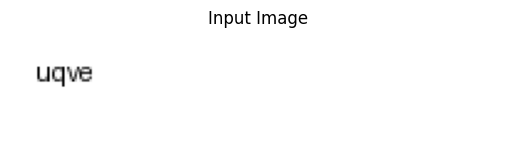

In [65]:
image = Image.open(img_path)
img_tensor = transform(image).unsqueeze(0)

plt.imshow(image, cmap='gray')
plt.title("Input Image")
plt.axis("off")

In [66]:
with torch.no_grad():
    img_tensor = img_tensor.to(device)
    outputs = model(img_tensor)
    preds = outputs.argmax(2)
    preds = preds[0].cpu().numpy()

In [67]:
chars = "abcdefghijklmnopqrstuvwxyz"

predicted_text = ""
prev_char = ""

for p in preds:
    if p < len(chars):
        current_char = chars[p]
        if current_char != prev_char:
            predicted_text += current_char
            prev_char = current_char

print(" Prediction:", predicted_text)

 Prediction: m


Text(0.5, 1.0, 'Prediction: m')

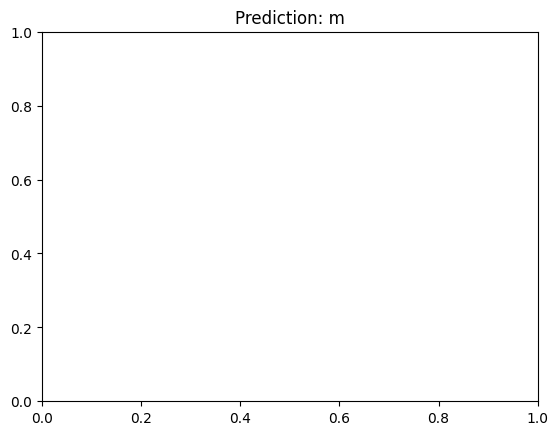

In [68]:
plt.title(f"Prediction: {predicted_text}")

In [75]:
torch.save(model.state_dict(), "/content/drive/MyDrive/renaissance_ocr_project/FINAL_MODEL_SUBMISSION.pth")
print("✅ Final Submission Model Saved")

✅ Final Submission Model Saved
